# Phase 4 — Modeling

**Goal:** Train a LightGBM fraud classifier on the engineered features from Phase 3.

**Modeling decisions (locked from EDA):**
- Algorithm: LightGBM. Reasons: handles NaN natively, fast on 472K rows, captures feature interactions tree-based models excel at.
- Imbalance handling: `scale_pos_weight=28` (≈ neg/pos ratio). No resampling — for tree models on severe imbalance, class weights typically match or outperform SMOTE while training faster.
- Evaluation metric for early stopping: **PR-AUC** (average_precision). Not ROC-AUC, because the high class imbalance makes ROC-AUC look misleadingly high — a useless model can still achieve ROC-AUC 0.90 on 3.5%-positive data.
- Operational metric: **Recall @ 1% FPR**. Translates to "if the ops team can review 1% of legit transactions, what fraction of frauds do we catch?"
- Threshold: optimized in Session 2 against a business cost matrix ($100 per missed fraud, $5 per false alarm).

In [1]:
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow

# Add project root to path
ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))

from src.models.train import train_lightgbm, compute_metrics, recall_at_fpr

# Paths
PROCESSED = ROOT / "data" / "processed"
MODELS_DIR = ROOT / "models"
FIGURES = ROOT / "reports" / "figures"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# MLflow tracking URI — store experiments in project root
mlflow.set_tracking_uri(f"file:{ROOT / 'mlruns'}")

# Plot styling
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (10, 6)

print("Setup complete.")
print(f"MLflow tracking: {mlflow.get_tracking_uri()}")

Setup complete.
MLflow tracking: file:C:\Projects\fraud-detection-system\mlruns


In [2]:
# Load engineered features
print("Loading engineered features from Phase 3 artifacts...")
X_train = pd.read_parquet(PROCESSED / "X_train.parquet")
X_val = pd.read_parquet(PROCESSED / "X_val.parquet")
y_train = pd.read_parquet(PROCESSED / "y_train.parquet")["isFraud"]
y_val = pd.read_parquet(PROCESSED / "y_val.parquet")["isFraud"]

print(f"X_train: {X_train.shape}  |  fraud rate: {y_train.mean()*100:.2f}%")
print(f"X_val:   {X_val.shape}  |  fraud rate: {y_val.mean()*100:.2f}%")

# Reapply categorical dtypes from fitted pipeline (Parquet round-trip prunes them)
import pickle
with open(MODELS_DIR / "feature_engineer.pkl", "rb") as f:
    fe = pickle.load(f)
for col, cats in fe.cat_categories_.items():
    if col in X_train.columns:
        X_train[col] = pd.Categorical(X_train[col].astype("object"), categories=cats)
    if col in X_val.columns:
        X_val[col] = pd.Categorical(X_val[col].astype("object"), categories=cats)

print("\nCategorical columns after restoration:")
for col in X_train.select_dtypes(include="category").columns:
    print(f"  {col:<15} categories={list(X_train[col].cat.categories)}")

Loading engineered features from Phase 3 artifacts...
X_train: (472432, 36)  |  fraud rate: 3.51%
X_val:   (118108, 36)  |  fraud rate: 3.44%

Categorical columns after restoration:
  ProductCD       categories=['C', 'H', 'R', 'S', 'W']
  card4           categories=['american express', 'discover', 'mastercard', 'missing', 'visa']
  card6           categories=['charge card', 'credit', 'debit', 'debit or credit', 'missing']
  DeviceType      categories=['desktop', 'missing', 'mobile']


In [3]:
# Baseline 1: Naive "always predict not fraud" — what's the accuracy?
naive_accuracy = (y_val == 0).mean()
print(f"Baseline 'always predict not fraud':")
print(f"  Accuracy: {naive_accuracy*100:.2f}%")
print(f"  Recall:   0.00% (catches no fraud)")
print(f"  This is why we don't use accuracy.\n")

# Baseline 2: Random scores (uniform)
np.random.seed(42)
random_scores = np.random.rand(len(y_val))
baseline_metrics = compute_metrics(y_val.values, random_scores, threshold=0.5)
print(f"Baseline 'random scores':")
print(f"  PR-AUC:           {baseline_metrics['pr_auc']:.4f}  (≈ fraud rate {y_val.mean():.4f})")
print(f"  ROC-AUC:          {baseline_metrics['roc_auc']:.4f}  (random = 0.5)")
print(f"  Recall @ 1% FPR:  {baseline_metrics['recall_at_1pct_fpr']:.4f}")

Baseline 'always predict not fraud':
  Accuracy: 96.56%
  Recall:   0.00% (catches no fraud)
  This is why we don't use accuracy.

Baseline 'random scores':
  PR-AUC:           0.0343  (≈ fraud rate 0.0344)
  ROC-AUC:          0.4983  (random = 0.5)
  Recall @ 1% FPR:  0.0091


In [4]:
# First real model — default hyperparameters
t0 = time.time()
model, metrics = train_lightgbm(
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    run_name="lgbm-baseline-default-params",
)
elapsed = time.time() - t0

print(f"\n=== Training complete in {elapsed:.1f}s ===\n")
print(f"Best iteration: {model.best_iteration}")
print(f"\nValidation metrics:")
for k, v in metrics.items():
    if isinstance(v, float):
        print(f"  {k:<25} {v:.4f}")
    else:
        print(f"  {k:<25} {v}")

[100]	train's average_precision: 0.599667	val's average_precision: 0.437105
[200]	train's average_precision: 0.661444	val's average_precision: 0.452013
[300]	train's average_precision: 0.710931	val's average_precision: 0.455018
[400]	train's average_precision: 0.751027	val's average_precision: 0.457041
[500]	train's average_precision: 0.784438	val's average_precision: 0.458744
[600]	train's average_precision: 0.812032	val's average_precision: 0.461471
[700]	train's average_precision: 0.835815	val's average_precision: 0.463461
[800]	train's average_precision: 0.858068	val's average_precision: 0.465607
[900]	train's average_precision: 0.877213	val's average_precision: 0.466871
[1000]	train's average_precision: 0.893977	val's average_precision: 0.468708
[1100]	train's average_precision: 0.909009	val's average_precision: 0.469909
[1200]	train's average_precision: 0.923254	val's average_precision: 0.471018
[1300]	train's average_precision: 0.933703	val's average_precision: 0.472287


2026/05/21 04:00:32 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



=== Training complete in 74.9s ===

Best iteration: 1250

Validation metrics:
  pr_auc                    0.4727
  roc_auc                   0.8983
  precision                 0.3382
  recall                    0.5984
  f1                        0.4321
  n_predicted_positive      7192
  threshold                 0.5000
  recall_at_1pct_fpr        0.4134


In [6]:
# Clean up failed runs from earlier debugging
client = MlflowClient()
experiment = client.get_experiment_by_name("fraud-detection")
runs = client.search_runs(experiment_ids=[experiment.experiment_id])

failed_run_ids = [run.info.run_id for run in runs if run.info.status == "FAILED"]
print(f"Found {len(failed_run_ids)} failed run(s) to delete")

for run_id in failed_run_ids:
    client.delete_run(run_id)
    print(f"  Deleted: {run_id[:8]}")

# Verify cleanup
remaining = client.search_runs(experiment_ids=[experiment.experiment_id])
print(f"\nRemaining runs: {len(remaining)}")
for run in remaining:
    print(f"  {run.data.tags.get('mlflow.runName', 'unnamed'):<35} Status: {run.info.status}  PR-AUC: {run.data.metrics.get('pr_auc', 0):.4f}")
    

Found 2 failed run(s) to delete
  Deleted: f45d62a4
  Deleted: 3cf00af7

Remaining runs: 1
  lgbm-baseline-default-params        Status: FINISHED  PR-AUC: 0.4727


## Session 2 — Hyperparameter tuning + threshold optimization

In [7]:
# The baseline overfit (train PR-AUC 0.93 vs val 0.47). Tighten regularization.
print("Run 2: stronger regularization")
model_v2, metrics_v2 = train_lightgbm(
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    params={
        "num_leaves": 31,            # was 63 — smaller trees, less memorization
        "min_child_samples": 200,    # was 100 — require more data per leaf
        "feature_fraction": 0.7,     # was 0.8 — drop more features per tree
        "bagging_fraction": 0.7,     # was 0.8 — drop more rows per tree
        "reg_alpha": 0.5,            # NEW — L1 regularization
        "reg_lambda": 0.5,           # NEW — L2 regularization
    },
    run_name="lgbm-stronger-regularization",
)

print(f"\nVal PR-AUC:           {metrics_v2['pr_auc']:.4f}  (baseline: 0.4727)")
print(f"Val Recall@1%FPR:     {metrics_v2['recall_at_1pct_fpr']:.4f}  (baseline: 0.4134)")
print(f"Best iteration:       {model_v2.best_iteration}")

Run 2: stronger regularization
[100]	train's average_precision: 0.537772	val's average_precision: 0.428442
[200]	train's average_precision: 0.584714	val's average_precision: 0.439829
[300]	train's average_precision: 0.61671	val's average_precision: 0.44483
[400]	train's average_precision: 0.644624	val's average_precision: 0.447505
[500]	train's average_precision: 0.667342	val's average_precision: 0.452925
[600]	train's average_precision: 0.688686	val's average_precision: 0.454645
[700]	train's average_precision: 0.70827	val's average_precision: 0.457858
[800]	train's average_precision: 0.726741	val's average_precision: 0.458691


2026/05/21 04:05:40 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



Val PR-AUC:           0.4596  (baseline: 0.4727)
Val Recall@1%FPR:     0.3863  (baseline: 0.4134)
Best iteration:       776


In [8]:
# Slower learning often produces better final models — at the cost of training time
print("Run 3: lower learning rate")
model_v3, metrics_v3 = train_lightgbm(
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    params={
        "num_leaves": 31,
        "min_child_samples": 200,
        "feature_fraction": 0.7,
        "bagging_fraction": 0.7,
        "reg_alpha": 0.5,
        "reg_lambda": 0.5,
        "learning_rate": 0.02,       # was 0.05 — slower learning
    },
    num_boost_round=5000,            # allow more rounds
    early_stopping_rounds=200,       # patience: 200 rounds without improvement
    run_name="lgbm-low-lr",
)

print(f"\nVal PR-AUC:           {metrics_v3['pr_auc']:.4f}")
print(f"Val Recall@1%FPR:     {metrics_v3['recall_at_1pct_fpr']:.4f}")
print(f"Best iteration:       {model_v3.best_iteration}")

Run 3: lower learning rate
[100]	train's average_precision: 0.496522	val's average_precision: 0.418081
[200]	train's average_precision: 0.532675	val's average_precision: 0.436578
[300]	train's average_precision: 0.55714	val's average_precision: 0.441167
[400]	train's average_precision: 0.575721	val's average_precision: 0.444468
[500]	train's average_precision: 0.589569	val's average_precision: 0.449058
[600]	train's average_precision: 0.604145	val's average_precision: 0.452408
[700]	train's average_precision: 0.616204	val's average_precision: 0.454018
[800]	train's average_precision: 0.627109	val's average_precision: 0.456791
[900]	train's average_precision: 0.638305	val's average_precision: 0.45833
[1000]	train's average_precision: 0.649154	val's average_precision: 0.459699
[1100]	train's average_precision: 0.659541	val's average_precision: 0.461406
[1200]	train's average_precision: 0.669448	val's average_precision: 0.462321
[1300]	train's average_precision: 0.677936	val's average_pre

2026/05/21 04:07:07 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



Val PR-AUC:           0.4626
Val Recall@1%FPR:     0.3974
Best iteration:       1223


                         run   pr_auc  roc_auc  recall_at_1pct_fpr  best_iter
lgbm-baseline-default-params 0.472667 0.898251            0.413386       1250
lgbm-stronger-regularization 0.459580 0.897539            0.386319        776
                 lgbm-low-lr 0.462611 0.898278            0.397392       1223


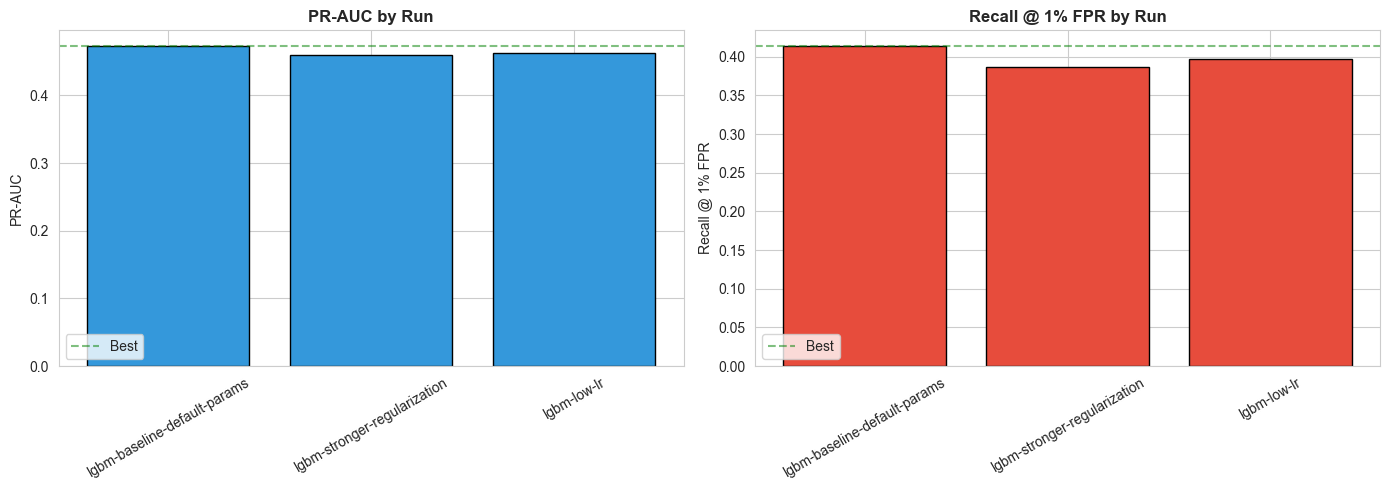

In [9]:
# Pull all runs from MLflow and compare
runs = client.search_runs(experiment_ids=[experiment.experiment_id], order_by=["start_time ASC"])

comparison = pd.DataFrame([{
    "run": r.data.tags.get("mlflow.runName", "unnamed"),
    "pr_auc": r.data.metrics.get("pr_auc"),
    "roc_auc": r.data.metrics.get("roc_auc"),
    "recall_at_1pct_fpr": r.data.metrics.get("recall_at_1pct_fpr"),
    "best_iter": int(r.data.metrics.get("best_iteration", 0)),
} for r in runs if r.info.status == "FINISHED"])

print(comparison.to_string(index=False))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(comparison["run"], comparison["pr_auc"], color="#3498db", edgecolor="black")
axes[0].set_title("PR-AUC by Run", fontweight="bold")
axes[0].set_ylabel("PR-AUC")
axes[0].tick_params(axis="x", rotation=30)
axes[0].axhline(comparison["pr_auc"].max(), color="green", linestyle="--", alpha=0.5, label="Best")
axes[0].legend()

axes[1].bar(comparison["run"], comparison["recall_at_1pct_fpr"], color="#e74c3c", edgecolor="black")
axes[1].set_title("Recall @ 1% FPR by Run", fontweight="bold")
axes[1].set_ylabel("Recall @ 1% FPR")
axes[1].tick_params(axis="x", rotation=30)
axes[1].axhline(comparison["recall_at_1pct_fpr"].max(), color="green", linestyle="--", alpha=0.5, label="Best")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES / "08_run_comparison.png", bbox_inches="tight")
plt.show()

=== Threshold optimization ===
Business cost matrix: $100/missed fraud, $5/false alarm
Validation set: 118,108 transactions (4,064 fraud)

Optimal threshold:    0.376
Optimal total cost:   $174,850
  Recall at threshold:    0.8076
  Precision at threshold: 0.1451
  False positives:        19,330

Baseline costs:
  Do nothing (catch no fraud):  $406,400
  Default 0.5 threshold cost:   $176,150
  Savings vs do-nothing:        $231,550


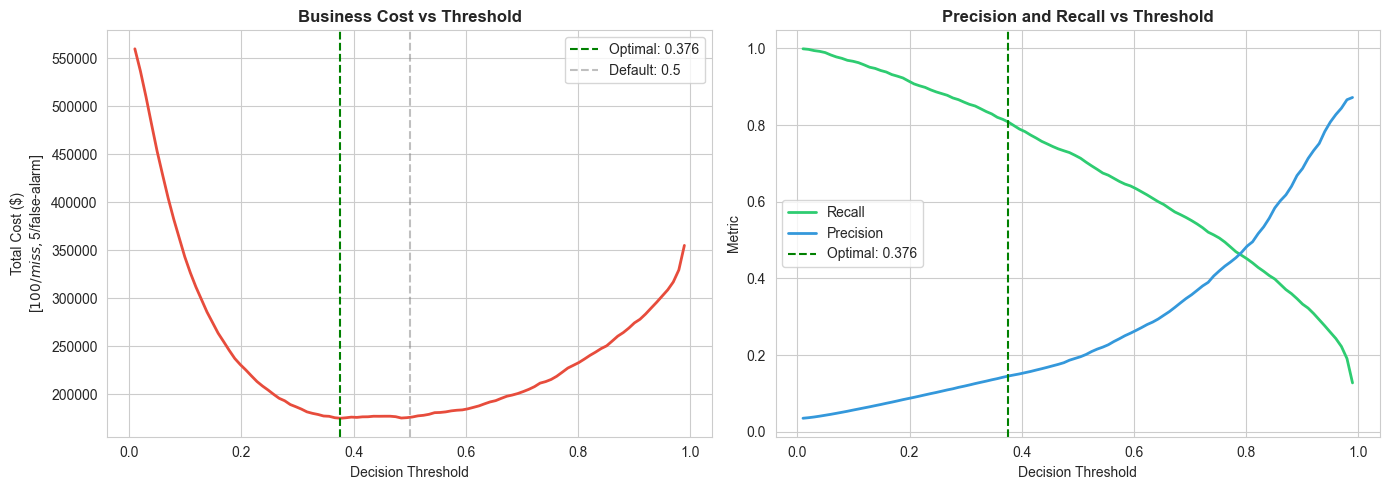

In [10]:
# Pick the best model
best_model = model_v3  # or whichever run gave you the best PR-AUC

# Business cost matrix: realistic numbers for credit card fraud
COST_FN = 100  # missed fraud — average fraud loss per transaction
COST_FP = 5   # false alarm — analyst review cost per flagged transaction

# Predict probabilities on val set
y_val_proba = best_model.predict(X_val, num_iteration=best_model.best_iteration)

# Scan thresholds and compute business cost at each
thresholds = np.linspace(0.01, 0.99, 100)
costs = []
recalls = []
precisions = []
fp_counts = []

for thr in thresholds:
    y_pred = (y_val_proba >= thr).astype(int)
    tp = ((y_pred == 1) & (y_val == 1)).sum()
    fp = ((y_pred == 1) & (y_val == 0)).sum()
    fn = ((y_pred == 0) & (y_val == 1)).sum()
    tn = ((y_pred == 0) & (y_val == 0)).sum()

    total_cost = fn * COST_FN + fp * COST_FP
    costs.append(total_cost)
    fp_counts.append(fp)
    recalls.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
    precisions.append(tp / (tp + fp) if (tp + fp) > 0 else 0)

optimal_idx = np.argmin(costs)
optimal_threshold = thresholds[optimal_idx]
optimal_cost = costs[optimal_idx]

# Compare to baseline costs
do_nothing_cost = (y_val == 1).sum() * COST_FN  # cost if we catch NO fraud
flag_all_cost = (y_val == 0).sum() * COST_FP + 0  # cost if we flag everything

print(f"=== Threshold optimization ===")
print(f"Business cost matrix: ${COST_FN}/missed fraud, ${COST_FP}/false alarm")
print(f"Validation set: {len(y_val):,} transactions ({(y_val == 1).sum():,} fraud)")
print()
print(f"Optimal threshold:    {optimal_threshold:.3f}")
print(f"Optimal total cost:   ${optimal_cost:,.0f}")
print(f"  Recall at threshold:    {recalls[optimal_idx]:.4f}")
print(f"  Precision at threshold: {precisions[optimal_idx]:.4f}")
print(f"  False positives:        {fp_counts[optimal_idx]:,}")
print()
print(f"Baseline costs:")
print(f"  Do nothing (catch no fraud):  ${do_nothing_cost:,.0f}")
print(f"  Default 0.5 threshold cost:   ${costs[np.argmin(np.abs(thresholds - 0.5))]:,.0f}")
print(f"  Savings vs do-nothing:        ${do_nothing_cost - optimal_cost:,.0f}")

# Plot: cost curve and precision-recall vs threshold
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(thresholds, costs, color="#e74c3c", linewidth=2)
axes[0].axvline(optimal_threshold, color="green", linestyle="--", label=f"Optimal: {optimal_threshold:.3f}")
axes[0].axvline(0.5, color="gray", linestyle="--", alpha=0.5, label="Default: 0.5")
axes[0].set_xlabel("Decision Threshold")
axes[0].set_ylabel(f"Total Cost ($)\n[${COST_FN}/miss, ${COST_FP}/false-alarm]")
axes[0].set_title("Business Cost vs Threshold", fontweight="bold")
axes[0].legend()

axes[1].plot(thresholds, recalls, label="Recall", color="#2ecc71", linewidth=2)
axes[1].plot(thresholds, precisions, label="Precision", color="#3498db", linewidth=2)
axes[1].axvline(optimal_threshold, color="green", linestyle="--", label=f"Optimal: {optimal_threshold:.3f}")
axes[1].set_xlabel("Decision Threshold")
axes[1].set_ylabel("Metric")
axes[1].set_title("Precision and Recall vs Threshold", fontweight="bold")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES / "09_threshold_optimization.png", bbox_inches="tight")
plt.show()

## Session 3 — SHAP Explainability and Production Artifacts

The model achieves PR-AUC 0.47 and recovers 81% of fraud at the optimal threshold of 0.376. Now we:
1. Compute SHAP values to understand which features drive fraud predictions
2. Save the production model, optimal threshold, and SHAP explainer for use by the FastAPI service in Phase 5

In [11]:
# Retrain the winning model as our "production" version
print("Training production model with best hyperparameters...")

prod_model, prod_metrics = train_lightgbm(
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    params={},  # default params (the winner)
    num_boost_round=2000,
    early_stopping_rounds=100,
    run_name="production-model",
)

print(f"\n=== Production model ===")
print(f"Best iteration:       {prod_model.best_iteration}")
print(f"Val PR-AUC:           {prod_metrics['pr_auc']:.4f}")
print(f"Val Recall@1%FPR:     {prod_metrics['recall_at_1pct_fpr']:.4f}")

Training production model with best hyperparameters...
[100]	train's average_precision: 0.599667	val's average_precision: 0.437105
[200]	train's average_precision: 0.661444	val's average_precision: 0.452013
[300]	train's average_precision: 0.710931	val's average_precision: 0.455018
[400]	train's average_precision: 0.751027	val's average_precision: 0.457041
[500]	train's average_precision: 0.784438	val's average_precision: 0.458744
[600]	train's average_precision: 0.812032	val's average_precision: 0.461471
[700]	train's average_precision: 0.835815	val's average_precision: 0.463461
[800]	train's average_precision: 0.858068	val's average_precision: 0.465607
[900]	train's average_precision: 0.877213	val's average_precision: 0.466871
[1000]	train's average_precision: 0.893977	val's average_precision: 0.468708
[1100]	train's average_precision: 0.909009	val's average_precision: 0.469909
[1200]	train's average_precision: 0.923254	val's average_precision: 0.471018
[1300]	train's average_precisi

2026/05/21 04:14:18 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



=== Production model ===
Best iteration:       1250
Val PR-AUC:           0.4727
Val Recall@1%FPR:     0.4134


In [12]:
import shap

# Initialize TreeExplainer — fast for tree models
print("Initializing SHAP TreeExplainer...")
explainer = shap.TreeExplainer(prod_model)

# Compute SHAP on a sample of validation data (full set takes too long)
SHAP_SAMPLE_SIZE = 5000
sample_idx = np.random.RandomState(42).choice(len(X_val), size=SHAP_SAMPLE_SIZE, replace=False)
X_val_sample = X_val.iloc[sample_idx].copy()

print(f"Computing SHAP values on {SHAP_SAMPLE_SIZE} validation samples...")
t0 = time.time()
shap_values = explainer.shap_values(X_val_sample)
print(f"  Computed in {time.time() - t0:.1f}s")

# For binary classification with LightGBM, shap_values is a single array
# (not a list of two arrays). Each value is the contribution to log-odds of fraud.
print(f"SHAP values shape: {shap_values.shape}")
print(f"Mean |SHAP|: {np.abs(shap_values).mean():.4f}")

Initializing SHAP TreeExplainer...
Computing SHAP values on 5000 validation samples...
  Computed in 14.2s
SHAP values shape: (5000, 36)
Mean |SHAP|: 0.1465


c:\Projects\fraud-detection-system\.venv\Lib\site-packages\shap\explainers\_tree.py:448: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn('LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray')


=== Top 20 Features by SHAP Importance ===
          feature  mean_abs_shap
              C13       0.635315
      amt_decimal       0.517243
       email_risk       0.300126
               C1       0.294684
               D1       0.287429
            addr1       0.283856
              D15       0.278696
               C2       0.246775
     uid_amt_mean       0.235475
               D2       0.233015
              amt       0.223501
      uid_amt_std       0.209850
    uid_txn_count       0.196320
        ProductCD       0.182028
            card6       0.177698
            card4       0.161498
uid_amt_deviation       0.106874
             hour       0.090637
          dow_sin       0.064202
    missing_id_02       0.058078


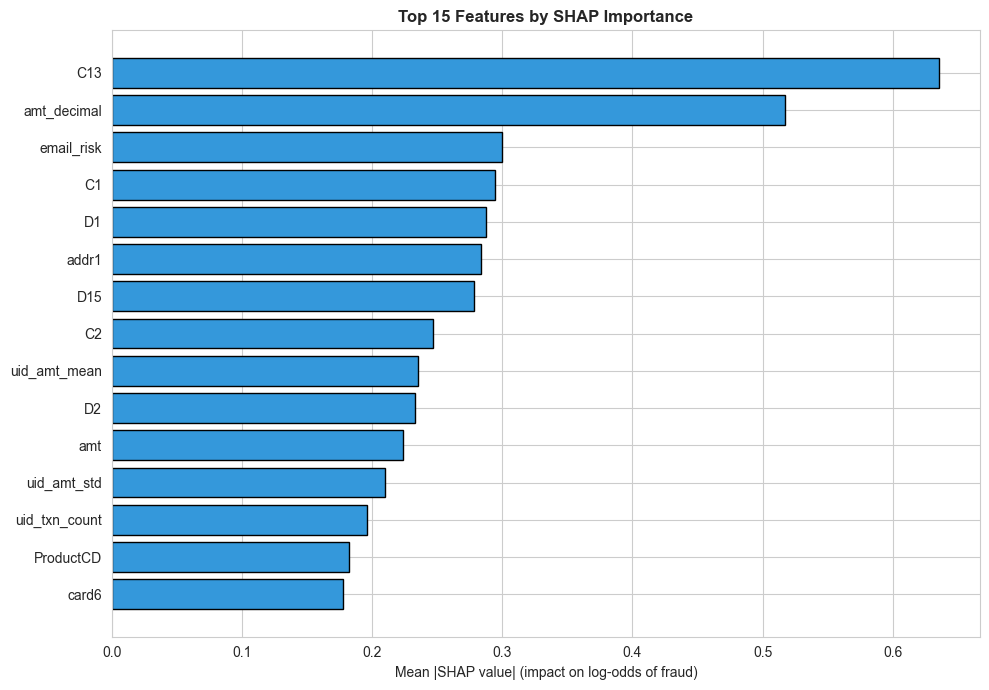

In [13]:
# Mean absolute SHAP value per feature = global importance
mean_abs_shap = np.abs(shap_values).mean(axis=0)
importance_df = pd.DataFrame({
    "feature": X_val_sample.columns,
    "mean_abs_shap": mean_abs_shap,
}).sort_values("mean_abs_shap", ascending=False)

print("=== Top 20 Features by SHAP Importance ===")
print(importance_df.head(20).to_string(index=False))

# Plot top 15
top_features = importance_df.head(15)
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_features["feature"], top_features["mean_abs_shap"], color="#3498db", edgecolor="black")
ax.set_xlabel("Mean |SHAP value| (impact on log-odds of fraud)")
ax.set_title("Top 15 Features by SHAP Importance", fontweight="bold")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIGURES / "10_shap_global_importance.png", bbox_inches="tight")
plt.show()

Generating SHAP summary plot...


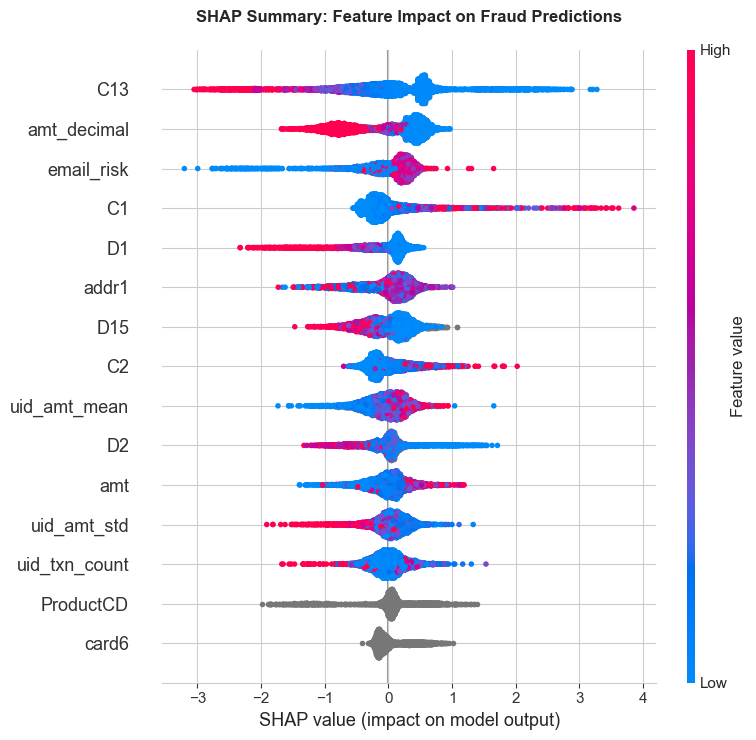

In [14]:
# The classic SHAP "beeswarm" — shows both importance AND directionality
print("Generating SHAP summary plot...")
fig = plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_val_sample,
    max_display=15,
    show=False,
)
plt.title("SHAP Summary: Feature Impact on Fraud Predictions", fontweight="bold", pad=20)
plt.tight_layout()
plt.savefig(FIGURES / "11_shap_summary_beeswarm.png", bbox_inches="tight", dpi=150)
plt.show()

In [15]:
# Pick a high-confidence fraud prediction from validation set
y_val_proba_full = prod_model.predict(X_val, num_iteration=prod_model.best_iteration)

# Find a confident true positive
true_positives_mask = (y_val == 1) & (y_val_proba_full > 0.8)
tp_indices = np.where(true_positives_mask)[0]
example_idx = tp_indices[0]

print(f"Explaining transaction at val index {example_idx}")
print(f"  True label:     {y_val.iloc[example_idx]} (fraud)")
print(f"  Model probability: {y_val_proba_full[example_idx]:.4f}")
print()

# Compute SHAP for this single transaction
single_shap = explainer.shap_values(X_val.iloc[[example_idx]])

# Top 5 contributing features for this prediction
contrib_df = pd.DataFrame({
    "feature": X_val.columns,
    "value": X_val.iloc[example_idx].values,
    "shap_contribution": single_shap[0],
}).sort_values("shap_contribution", key=abs, ascending=False)

print("Top 5 features pushing this prediction toward FRAUD:")
print(contrib_df.head(5).to_string(index=False))

Explaining transaction at val index 78
  True label:     1 (fraud)
  Model probability: 0.9983

Top 5 features pushing this prediction toward FRAUD:
  feature  value  shap_contribution
       C1   36.0           3.499799
      C13    0.0           2.799639
ProductCD      C           1.024454
    addr1    NaN           0.427754
    card6 credit           0.398726


c:\Projects\fraud-detection-system\.venv\Lib\site-packages\shap\explainers\_tree.py:448: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn('LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray')


In [16]:
import joblib

# Save the LightGBM model (we use joblib here — lighter than mlflow.lightgbm.save_model)
joblib.dump(prod_model, MODELS_DIR / "fraud_model.pkl")
print(f"Saved fraud_model.pkl ({(MODELS_DIR / 'fraud_model.pkl').stat().st_size / 1024**2:.1f} MB)")

# Save the SHAP explainer
joblib.dump(explainer, MODELS_DIR / "shap_explainer.pkl")
print(f"Saved shap_explainer.pkl ({(MODELS_DIR / 'shap_explainer.pkl').stat().st_size / 1024**2:.1f} MB)")

# Save the optimal threshold + model metadata as JSON
import json

metadata = {
    "model_type": "LightGBM",
    "best_iteration": int(prod_model.best_iteration),
    "n_features": int(X_train.shape[1]),
    "feature_names": list(X_train.columns),
    "categorical_features": list(X_train.select_dtypes(include="category").columns),
    "optimal_threshold": float(optimal_threshold),
    "cost_matrix": {
        "cost_false_negative": COST_FN,
        "cost_false_positive": COST_FP,
    },
    "validation_metrics": {k: float(v) if isinstance(v, (int, float, np.floating)) else v 
                           for k, v in prod_metrics.items()},
    "training_date": pd.Timestamp.now().isoformat(),
}

with open(MODELS_DIR / "model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print(f"Saved model_metadata.json")

# Verify everything
print("\n=== Production artifacts in models/ ===")
for path in sorted(MODELS_DIR.glob("*")):
    size_mb = path.stat().st_size / 1024**2
    print(f"  {path.name:<30} ({size_mb:.2f} MB)")

Saved fraud_model.pkl (8.2 MB)
Saved shap_explainer.pkl (8.3 MB)
Saved model_metadata.json

=== Production artifacts in models/ ===
  feature_engineer.pkl           (4.11 MB)
  fraud_model.pkl                (8.25 MB)
  model_metadata.json            (0.00 MB)
  shap_explainer.pkl             (8.25 MB)


In [18]:
# Simulate what the FastAPI service will do
print("=== End-to-end inference test ===")
RAW = ROOT / "data" / "raw"
print("Loading all production artifacts from disk...")

with open(MODELS_DIR / "feature_engineer.pkl", "rb") as f:
    fe_prod = pickle.load(f)
model_prod = joblib.load(MODELS_DIR / "fraud_model.pkl")
explainer_prod = joblib.load(MODELS_DIR / "shap_explainer.pkl")
with open(MODELS_DIR / "model_metadata.json") as f:
    meta = json.load(f)

print(f"All artifacts loaded.")
print(f"Optimal threshold from metadata: {meta['optimal_threshold']:.3f}")

# Take a raw transaction from the validation set (simulating a production request)
# We need the RAW merged data, not the engineered features, because the pipeline does the engineering
print("\nSimulating prediction on a raw validation transaction...")

# Reload the raw data for this one example
raw_txn = pd.read_csv(RAW / "train_transaction.csv", nrows=1000)
raw_id = pd.read_csv(RAW / "train_identity.csv")
raw_merged = raw_txn.merge(raw_id, on="TransactionID", how="left")
sample_raw = raw_merged.iloc[[500]]  # one transaction

# Run through the pipeline
print(f"  Raw input shape: {sample_raw.shape}")
X_engineered = fe_prod.transform(sample_raw)
print(f"  After feature engineering: {X_engineered.shape}")

# Restore categoricals (Parquet pruning isn't an issue here since this is fresh from fe.transform)
proba = model_prod.predict(X_engineered, num_iteration=model_prod.best_iteration)[0]
is_fraud = bool(proba >= meta['optimal_threshold'])
print(f"\n  Predicted probability:   {proba:.4f}")
print(f"  Threshold:               {meta['optimal_threshold']:.4f}")
print(f"  Decision:                {'FLAG AS FRAUD' if is_fraud else 'allow'}")

# Compute SHAP for this prediction
shap_val = explainer_prod.shap_values(X_engineered)
top_contributors = pd.DataFrame({
    "feature": X_engineered.columns,
    "value": X_engineered.iloc[0].values,
    "shap": shap_val[0],
}).sort_values("shap", key=abs, ascending=False).head(5)

print(f"\n  Top 5 contributing features:")
print(top_contributors.to_string(index=False))

print("\n✅ End-to-end pipeline works. Phase 5 (FastAPI) can load these artifacts directly.")

=== End-to-end inference test ===
Loading all production artifacts from disk...
All artifacts loaded.
Optimal threshold from metadata: 0.376

Simulating prediction on a raw validation transaction...
  Raw input shape: (1, 434)
  After feature engineering: (1, 36)

  Predicted probability:   0.0582
  Threshold:               0.3763
  Decision:                allow

  Top 5 contributing features:
feature  value      shap
    C13    1.0  0.558446
     C1    1.0 -0.314498
     C2    1.0 -0.240204
    amt  108.5  0.232335
  card6  debit -0.201704

✅ End-to-end pipeline works. Phase 5 (FastAPI) can load these artifacts directly.


c:\Projects\fraud-detection-system\.venv\Lib\site-packages\shap\explainers\_tree.py:448: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn('LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray')


In [19]:
# Diagnose what shap_val looks like
print(f"type(shap_val): {type(shap_val)}")
if isinstance(shap_val, list):
    print(f"len(shap_val): {len(shap_val)}")
    print(f"shap_val[0].shape: {shap_val[0].shape}")
    print(f"shap_val[1].shape: {shap_val[1].shape}")
else:
    print(f"shap_val.shape: {shap_val.shape}")

# Same diagnostic for the bulk SHAP values from Cell N+7
print(f"\ntype(shap_values): {type(shap_values)}")
if isinstance(shap_values, list):
    print(f"len(shap_values): {len(shap_values)}")
    print(f"shap_values[0].shape: {shap_values[0].shape}")
    print(f"shap_values[1].shape: {shap_values[1].shape}")
else:
    print(f"shap_values.shape: {shap_values.shape}")

type(shap_val): <class 'numpy.ndarray'>
shap_val.shape: (1, 36)

type(shap_values): <class 'numpy.ndarray'>
shap_values.shape: (5000, 36)
